In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [46]:
heart_disease_data = pd.read_csv('heart.csv')
df = heart_disease_data.copy()

In [47]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [48]:
df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [49]:
df.shape

(918, 12)

In [50]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [51]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [53]:
df.duplicated().sum()

np.int64(0)

***Univariate Analysis***

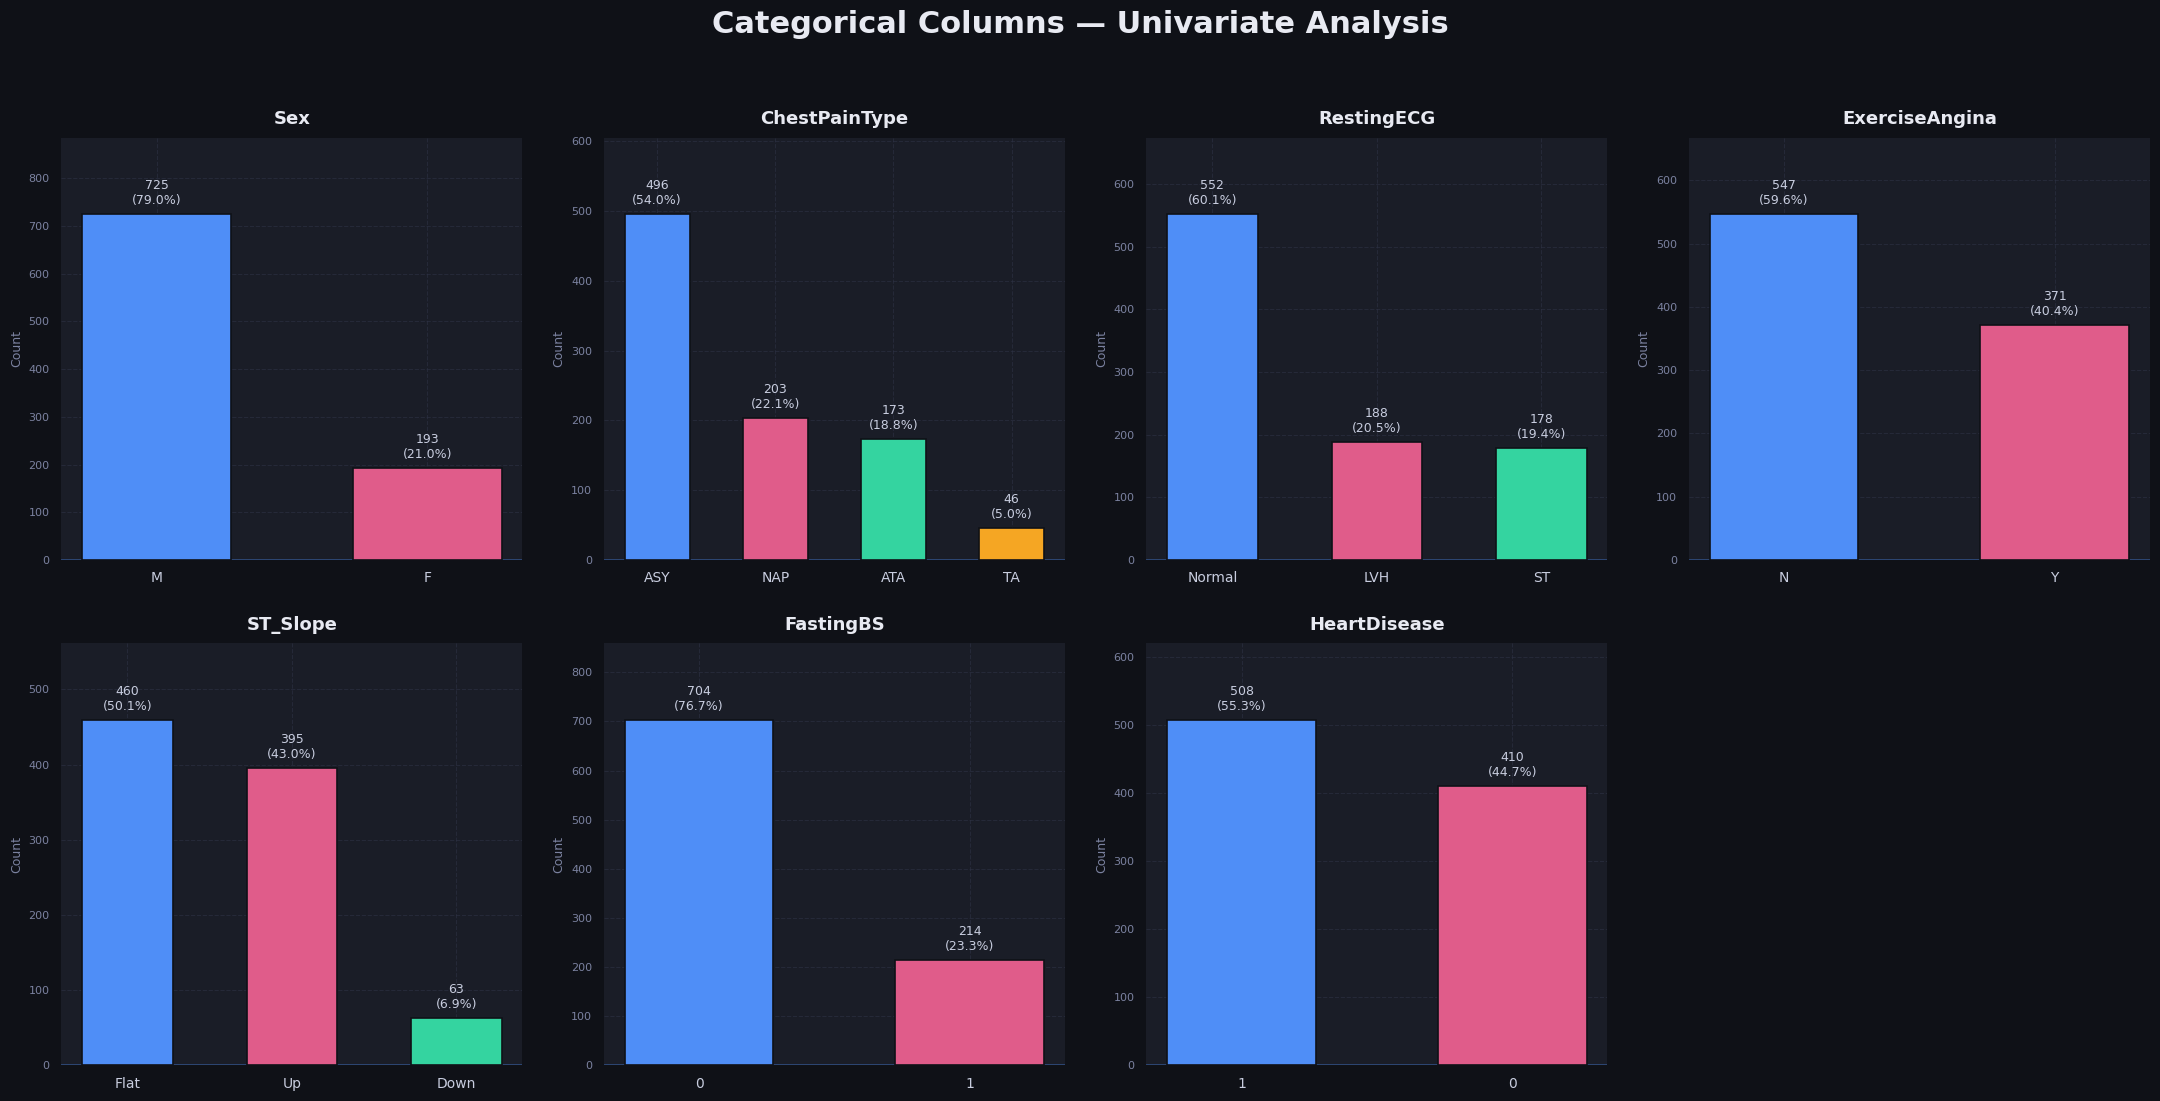

✅ Figure 1 saved — categorical_univariate.png


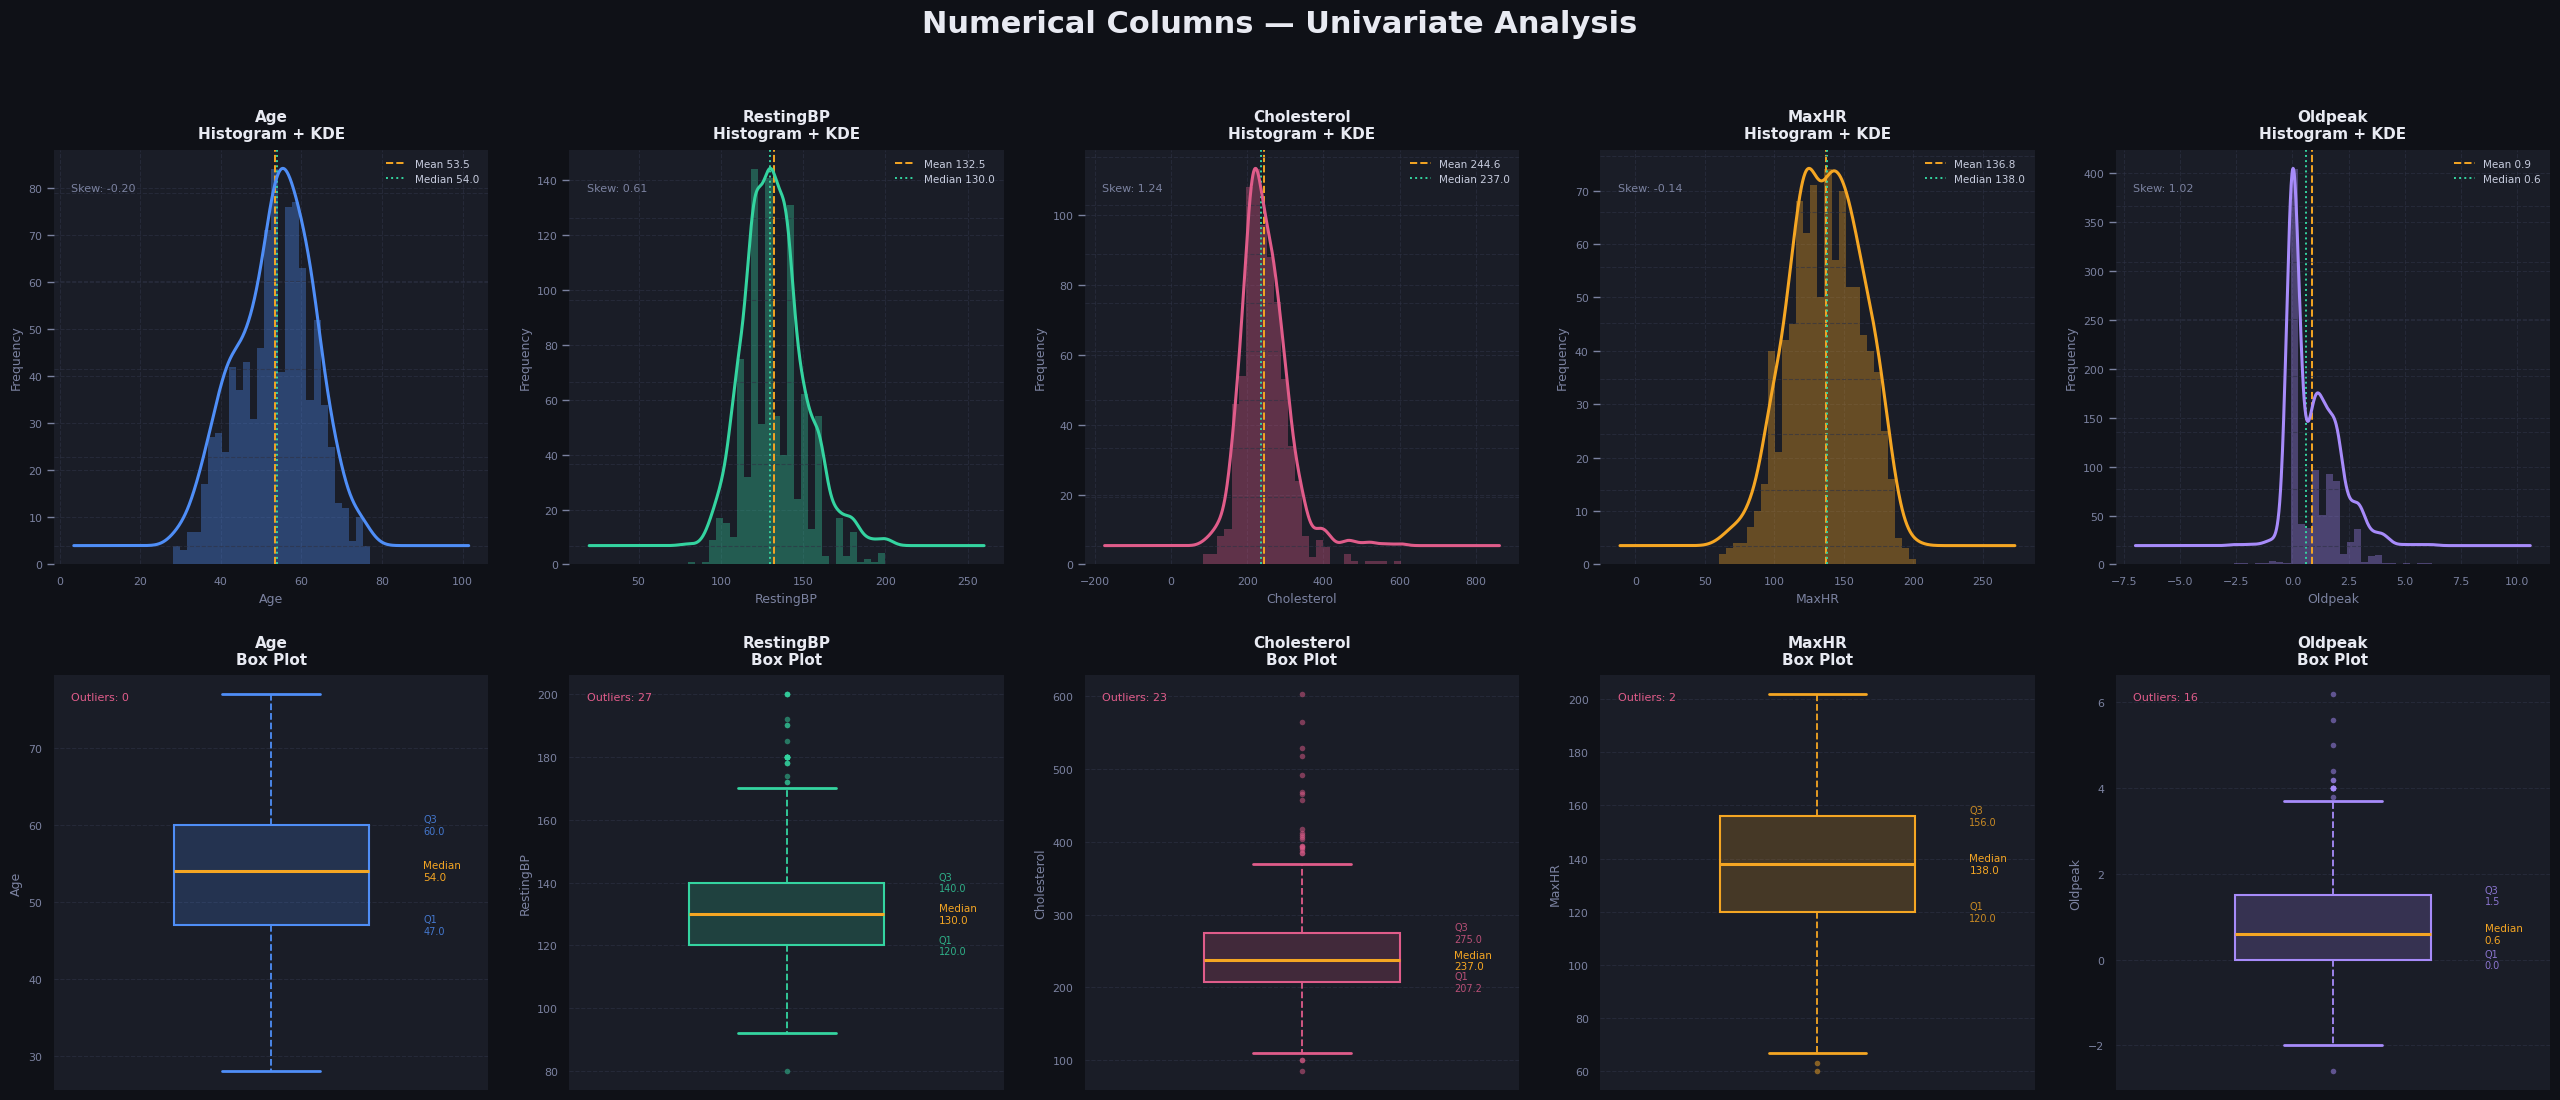

✅ Figure 2 saved — numerical_univariate.png


In [54]:

# ─────────────────────────────────────────
# GLOBAL STYLE SETTINGS
# ─────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0F1117',
    'axes.facecolor':   '#1A1D27',
    'axes.edgecolor':   '#2E3245',
    'axes.labelcolor':  '#C8CDDF',
    'xtick.color':      '#7B82A0',
    'ytick.color':      '#7B82A0',
    'text.color':       '#E8EAF2',
    'grid.color':       '#2E3245',
    'grid.linestyle':   '--',
    'grid.alpha':       0.6,
    'font.family':      'DejaVu Sans',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.spines.left':   False,
    'axes.spines.bottom': False,
})

CAT_COLORS  = ['#4F8EF7', '#E05C8A', '#34D4A0', '#F5A623', '#A78BFA', '#F97316', '#22D3EE']
NUM_PALETTE = ['#4F8EF7', '#34D4A0', '#E05C8A', '#F5A623', '#A78BFA']

# ─────────────────────────────────────────
# FIGURE 1 — CATEGORICAL COLUMNS
# ─────────────────────────────────────────
cat_cols = ['Sex', 'ChestPainType', 'RestingECG',
            'ExerciseAngina', 'ST_Slope', 'FastingBS', 'HeartDisease']

fig, axes = plt.subplots(2, 4, figsize=(22, 11))
fig.patch.set_facecolor('#0F1117')
fig.suptitle('Categorical Columns — Univariate Analysis',
             fontsize=22, fontweight='bold', color='#E8EAF2',
             y=1.01, x=0.5)

axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]
    counts  = df[col].value_counts()
    colors  = CAT_COLORS[:len(counts)]
    bars    = ax.bar(counts.index.astype(str), counts.values,
                     color=colors, width=0.55, zorder=3,
                     edgecolor='#0F1117', linewidth=1.2)

    # Value labels on top of bars
    for bar, val in zip(bars, counts.values):
        pct = f'{val/len(df)*100:.1f}%'
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(counts.values)*0.02,
                f'{val}\n({pct})',
                ha='center', va='bottom',
                fontsize=9, color='#C8CDDF', fontweight='500')

    ax.set_title(col, fontsize=13, fontweight='bold',
                 color='#E8EAF2', pad=10)
    ax.set_xlabel('')
    ax.set_ylabel('Count', fontsize=9, color='#7B82A0')
    ax.set_ylim(0, max(counts.values) * 1.22)
    ax.yaxis.grid(True, zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(axis='x', labelsize=10, colors='#C8CDDF')
    ax.tick_params(axis='y', labelsize=8)

    # Subtle bottom accent line
    ax.axhline(0, color=colors[0], linewidth=2, alpha=0.4)

# Hide last empty subplot
axes[-1].set_visible(False)

plt.tight_layout(pad=2.5)
plt.savefig('categorical_univariate.png', dpi=150,
            bbox_inches='tight', facecolor='#0F1117')
plt.show()
print("✅ Figure 1 saved — categorical_univariate.png")


# ─────────────────────────────────────────
# FIGURE 2 — NUMERICAL COLUMNS
# ─────────────────────────────────────────
num_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

fig, axes = plt.subplots(2, 5, figsize=(26, 11))
fig.patch.set_facecolor('#0F1117')
fig.suptitle('Numerical Columns — Univariate Analysis',
             fontsize=22, fontweight='bold', color='#E8EAF2',
             y=1.01)

# Row 1 → Histograms with KDE
for i, col in enumerate(num_cols):
    ax   = axes[0, i]
    clr  = NUM_PALETTE[i]
    data = df[col].dropna()
    data = data[data != 0] if col in ['Cholesterol', 'RestingBP'] else data

    ax.hist(data, bins=28, color=clr, alpha=0.35,
            edgecolor='none', zorder=2)

    ax2 = ax.twinx()
    kde_data = data.plot.kde(ax=ax2, color=clr,
                              linewidth=2.2, zorder=3)
    ax2.set_ylabel('')
    ax2.tick_params(left=False, right=False,
                    labelleft=False, labelright=False)
    ax2.set_facecolor('#1A1D27')
    for sp in ax2.spines.values():
        sp.set_visible(False)

    # Mean & median lines
    mean_v   = data.mean()
    median_v = data.median()
    ax.axvline(mean_v,   color='#F5A623', linestyle='--',
               linewidth=1.4, label=f'Mean {mean_v:.1f}', zorder=4)
    ax.axvline(median_v, color='#34D4A0', linestyle=':',
               linewidth=1.4, label=f'Median {median_v:.1f}', zorder=4)

    ax.set_title(f'{col}\nHistogram + KDE',
                 fontsize=11, fontweight='bold',
                 color='#E8EAF2', pad=8)
    ax.set_xlabel(col, fontsize=9, color='#7B82A0')
    ax.set_ylabel('Frequency', fontsize=9, color='#7B82A0')
    ax.yaxis.grid(True, zorder=0)
    ax.set_axisbelow(True)
    ax.legend(fontsize=7.5, framealpha=0,
              labelcolor='#C8CDDF', loc='upper right')

    # Skewness annotation
    skew_val = data.skew()
    ax.text(0.04, 0.92, f'Skew: {skew_val:.2f}',
            transform=ax.transAxes, fontsize=8,
            color='#7B82A0', va='top')

# Row 2 → Box plots
for i, col in enumerate(num_cols):
    ax  = axes[1, i]
    clr = NUM_PALETTE[i]
    data = df[col].dropna()
    data = data[data != 0] if col in ['Cholesterol', 'RestingBP'] else data

    bp = ax.boxplot(data, vert=True, patch_artist=True,
                    widths=0.45,
                    boxprops    = dict(facecolor=clr+'33', color=clr, linewidth=1.5),
                    medianprops = dict(color='#F5A623', linewidth=2.2),
                    whiskerprops= dict(color=clr, linewidth=1.3, linestyle='--'),
                    capprops    = dict(color=clr, linewidth=2),
                    flierprops  = dict(marker='o', markerfacecolor=clr,
                                       markersize=4, alpha=0.5,
                                       markeredgecolor='none'))

    # Stats annotations
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    ax.text(1.35, data.median(), f'Median\n{data.median():.1f}',
            fontsize=7.5, color='#F5A623', va='center')
    ax.text(1.35, q1, f'Q1\n{q1:.1f}',
            fontsize=7, color=clr, va='center', alpha=0.8)
    ax.text(1.35, q3, f'Q3\n{q3:.1f}',
            fontsize=7, color=clr, va='center', alpha=0.8)

    ax.set_title(f'{col}\nBox Plot',
                 fontsize=11, fontweight='bold',
                 color='#E8EAF2', pad=8)
    ax.set_ylabel(col, fontsize=9, color='#7B82A0')
    ax.set_xticks([])
    ax.yaxis.grid(True, zorder=0)
    ax.set_axisbelow(True)

    # Outlier count
    iqr     = q3 - q1
    out_cnt = ((data < q1 - 1.5*iqr) | (data > q3 + 1.5*iqr)).sum()
    ax.text(0.04, 0.96, f'Outliers: {out_cnt}',
            transform=ax.transAxes, fontsize=8,
            color='#E05C8A', va='top')

plt.tight_layout(pad=2.5)
plt.savefig('numerical_univariate.png', dpi=150,
            bbox_inches='tight', facecolor='#0F1117')
plt.show()
print("✅ Figure 2 saved — numerical_univariate.png")

***Bivariate Analysis***



1.***Categorical vs Disease***



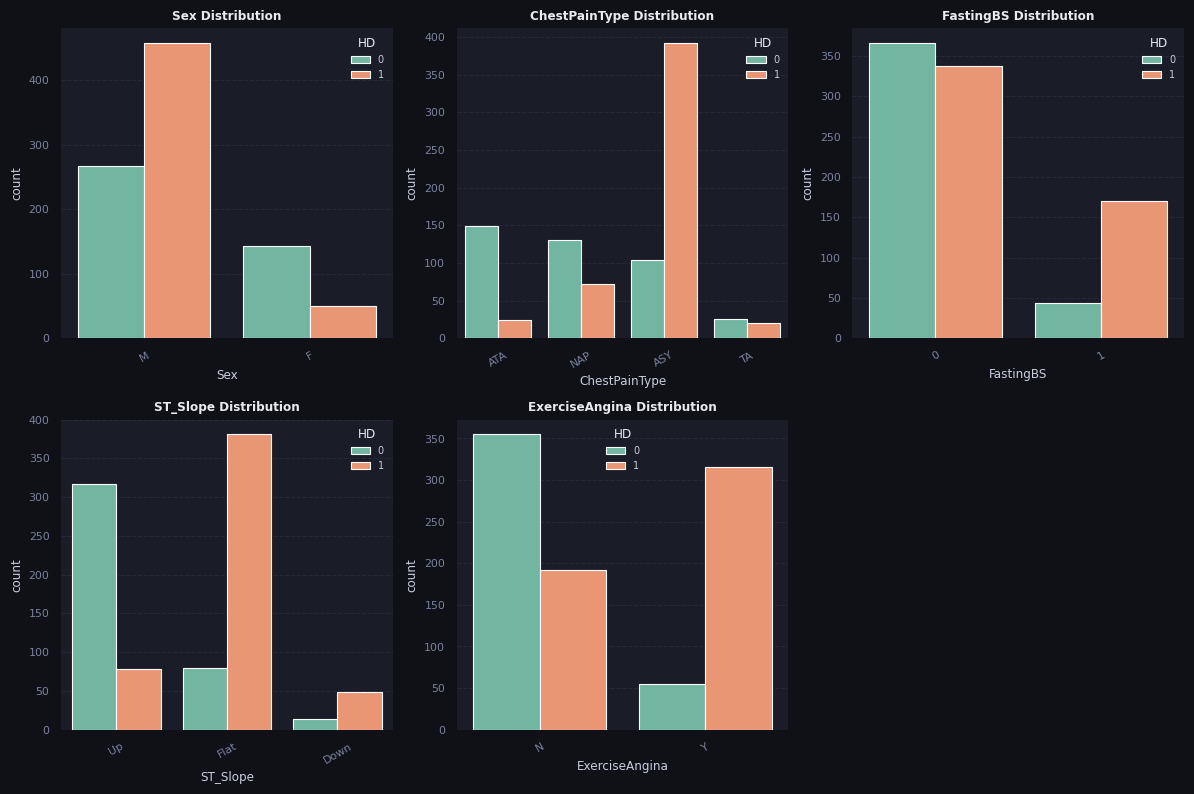

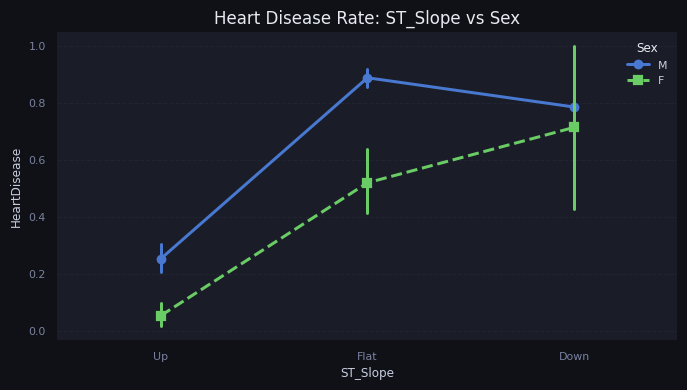

In [55]:
# Aesthetics setup
sns.set_context("paper", font_scale=0.9)
plt.style.use('seaborn-v0_8-muted')

# Categorical columns list
cat_vars = ['Sex', 'ChestPainType', 'FastingBS', 'ST_Slope', 'ExerciseAngina']

# 1. Compact Grid of Countplots
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(cat_vars):
    sns.countplot(data=df, x=col, hue='HeartDisease', ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} Distribution', fontweight='bold')
    axes[i].legend(title='HD', prop={'size': 7})
    axes[i].tick_params(axis='x', rotation=30)

# Extra plot delete kar dete hain agar empty ho
if len(cat_vars) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

# 2. Multivariate "Point Plot" (Best for 3+ categorical variables)
# Yeh dikhayega Sex, ST_Slope aur HeartDisease ka relation ek sath
plt.figure(figsize=(8, 4))
sns.pointplot(data=df, x="ST_Slope", y="HeartDisease", hue="Sex", markers=["o", "s"], linestyles=["-", "--"])
plt.title("Heart Disease Rate: ST_Slope vs Sex", fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

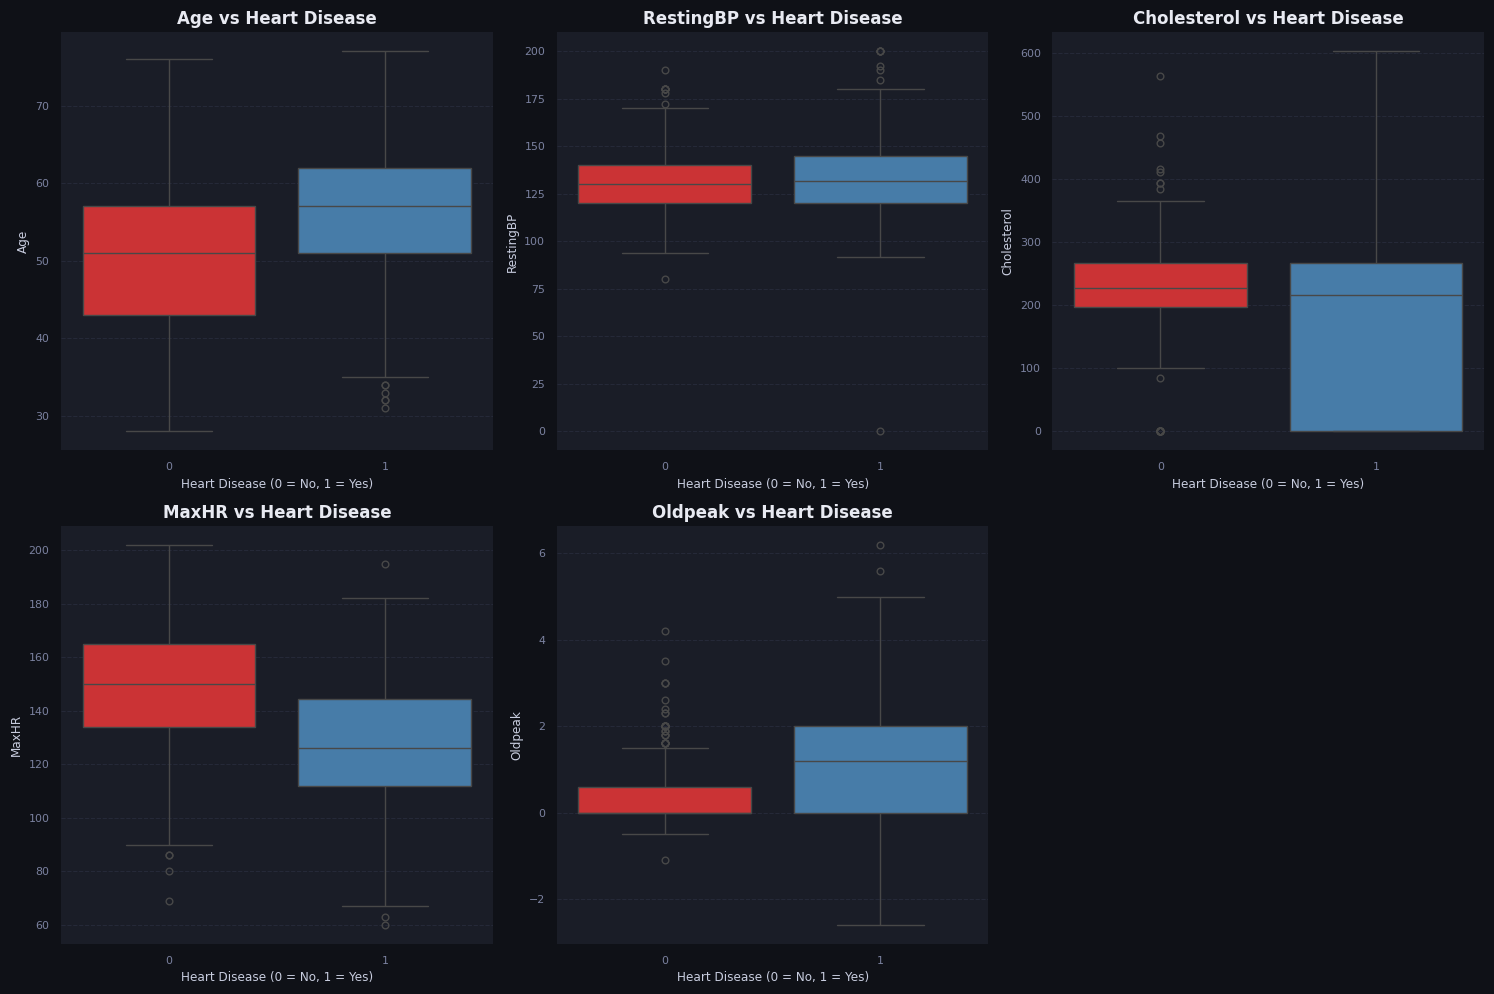

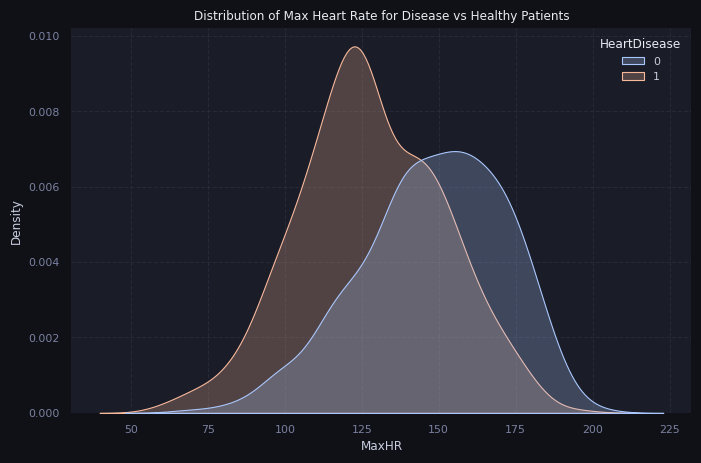

In [ ]:
# Identify numerical features
num_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

# Set the figure size for a compact layout
plt.figure(figsize=(15, 10))

for i, col in enumerate(num_features, 1):
    plt.subplot(2, 3, i)

    # BOXPLOT: Perfect for identifying outliers and median differences
    # Comment: Comparing the distribution of each numerical variable against Heart Disease
    sns.boxplot(data=df, x='HeartDisease', y=col, palette='Set1')

    plt.title(f'{col} vs Heart Disease', fontsize=12, fontweight='bold')
    plt.xlabel('Heart Disease (0 = No, 1 = Yes)')

plt.tight_layout()
plt.show()

# KDE PLOT: To see the overlap and density
# Comment: Visualizing the density overlap to see where the risk is highest
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='MaxHR', hue='HeartDisease', fill=True, palette='coolwarm')
plt.title('Distribution of Max Heart Rate for Disease vs Healthy Patients')
plt.show()

In [57]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [58]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
